# Pandas introduction

Import the pandas package, and set matplotlib inline.

In [1]:
import io
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from pandas import set_option
set_option("display.max_rows", 16)
LARGE_FIGSIZE = (12, 8)

Not that we're suspicous, but this notebook was last updated for pandas 2.1.x, in case of trouble, check this with the version number below.  Things have been know to break between 0.15.x and 0.16.x.

In [3]:
pd.__version__

'3.0.0'

## Importing data

Read a whitespace-separated file of data, set index to the first column, and parse it since those are dates.

In [4]:
full_globe_temp = pd.read_table(
    'data/temperatures/annual.land_ocean.90S.90N.df_1901-2000mean.dat',
    sep=r'\s+',
    names=['year', 'mean temp'],
    index_col=0,
    parse_dates=True
)
full_globe_temp

,mean temp
year,
1880-01-01,-0.1591
1881-01-01,-0.0789
1882-01-01,-0.1313
1883-01-01,-0.1675
1884-01-01,-0.2485
...,...
2006-01-01,0.5601
2007-01-01,0.5472
2008-01-01,0.4804


Reading a somewhat more involved data file having a header and footer that should be skipped.

In [5]:
giss_temp = pd.read_fwf(
    io.StringIO(''.join(
        line for line in open('data/temperatures/GLB.Ts+dSST.txt', encoding='utf-8')
        if re.match(r'^\s*\d{4}\s', line)
    )),
    names=[
        'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec',
        'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON',
        'Year_again'
    ],
    na_values=['****', '***'],
)
giss_temp

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON,Year_again
0,1880,-34,-27,-22,-30,-16.0,-24.0,-19.0,-12.0,-20.0,-19.0,-16.0,-21.0,-22.0,NaN,NaN,-23.0,-18.0,-18.0,1880
1,1881,-13,-16,-2,-3,-3.0,-27.0,-12.0,-8.0,-18.0,-23.0,-28.0,-18.0,-14.0,-14.0,-17.0,-3.0,-15.0,-23.0,1881
2,1882,3,4,-2,-24,-20.0,-32.0,-27.0,-11.0,-11.0,-25.0,-25.0,-37.0,-17.0,-16.0,-4.0,-15.0,-23.0,-20.0,1882
3,1883,-38,-38,-12,-20,-20.0,-8.0,-3.0,-13.0,-19.0,-19.0,-28.0,-21.0,-20.0,-21.0,-38.0,-18.0,-8.0,-22.0,1883
4,1884,-20,-14,-31,-36,-33.0,-36.0,-31.0,-24.0,-29.0,-25.0,-29.0,-25.0,-28.0,-28.0,-18.0,-33.0,-31.0,-28.0,1884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,2011,45,44,57,60,47.0,54.0,70.0,69.0,52.0,60.0,50.0,48.0,55.0,55.0,45.0,55.0,64.0,54.0,2011
132,2012,38,43,52,62,71.0,59.0,50.0,56.0,68.0,73.0,69.0,46.0,57.0,57.0,43.0,62.0,55.0,70.0,2012
133,2013,62,52,60,48,56.0,61.0,53.0,61.0,73.0,61.0,75.0,61.0,60.0,59.0,53.0,55.0,58.0,70.0,2013
134,2014,68,44,71,72,79.0,62.0,50.0,74.0,81.0,78.0,64.0,74.0,68.0,67.0,58.0,74.0,62.0,74.0,2014


In [6]:
co2 = pd.read_table(
    'data/greenhouse_gaz/co2_mm_global.txt',
    sep=r'\s+',
)
co2

,year,month,decimal,average,trend
0,1980,1,1980.042,338.45,337.82
1,1980,2,1980.125,339.17,338.12
2,1980,3,1980.208,339.49,338.14
3,1980,4,1980.292,339.87,338.25
4,1980,5,1980.375,340.30,338.78
...,...,...,...,...,...
419,2014,12,2014.958,398.62,398.08
420,2015,1,2015.042,399.31,398.29
421,2015,2,2015.125,400.01,398.59
422,2015,3,2015.208,400.59,398.96


In [7]:
northren_sea_level = pd.read_table(
    'data/sea_levels/sl_nh.txt',
    sep=r'\s+',
    usecols=[0, 1]
)
northren_sea_level

,year,msl_ib(mm)
0,1992.9323,13.717
1,1992.9595,1.328
2,1992.9866,-13.375
3,1993.0138,-24.723
4,1993.0409,-29.231
...,...,...
812,2015.0309,39.398
813,2015.0580,31.524
814,2015.0852,33.878
815,2015.1123,29.822


In [8]:
southren_sea_level = pd.read_table(
    'data/sea_levels/sl_sh.txt',
    sep=r'\s+',
    usecols=[0, 1]
)
southren_sea_level

,year,msl_ib(mm)
0,1992.9323,2.517
1,1992.9595,-7.645
2,1992.9866,-2.267
3,1993.0138,0.855
4,1993.0409,-2.020
...,...,...
812,2015.0309,69.746
813,2015.0580,69.317
814,2015.0852,77.533
815,2015.1123,81.370


In [9]:
global_sea_level = pd.read_table(
    'data/sea_levels/sl_ns_global.txt',
    sep=r'\s+',
    usecols=[0, 1]
)
global_sea_level

,year,msl_ib_ns(mm)
0,1992.9595,-5.818
1,1992.9866,-7.525
2,1993.0138,-9.215
3,1993.0409,-11.796
4,1993.0681,-11.291
...,...,...
775,2015.0309,64.804
776,2015.0580,62.115
777,2015.0852,68.589
778,2015.1123,69.745


Reading tables from the web is easy, it results in a list of all tables on a page.

In [10]:
table_list = pd.read_html(
    'http://www.psmsl.org/data/obtaining/'
)
local_sea_level_stations = table_list[0]
local_sea_level_stations

,Station Name,ID,Lat.,Lon.,GLOSS ID,Country,Date,Coastline,Station
0,BREST,1,48.383,-4.495,242.0,FRA,04/07/2025,190,091
1,SWINOUJSCIE,2,53.917,14.233,NaN,POL,19/10/2001,110,092
2,SHEERNESS,3,51.446,0.743,NaN,GBR,19/02/2025,170,101
3,HOLYHEAD,5,53.314,-4.620,NaN,GBR,18/02/2025,170,191
4,CUXHAVEN 2,7,53.867,8.717,284.0,DEU,22/11/2024,140,012
...,...,...,...,...,...,...,...,...,...
1606,KILRUSH LOUGH,2477,52.632,-9.502,NaN,IRL,13/11/2025,xxx,xxx
1607,ROONAGH PIER,2478,53.763,-9.905,NaN,IRL,13/11/2025,xxx,xxx
1608,ROSSLARE HARBOUR,2479,52.255,-6.665,NaN,IRL,13/11/2025,xxx,xxx
1609,SLIGO â€“ ROSSES POINT,2480,54.305,-8.569,NaN,IRL,13/11/2025,xxx,xxx


Data can also be read from Excel files (given that the necessary Python packages are installed).

In [11]:
sales = pd.read_excel(
    'data/sales-funnel.xlsx'
)
sales

,Account,Name,Rep,Manager,Product,Quantity,Price,Status
0,714466,Trantow-Barrows,Craig Booker,Debra Henley,CPU,1,30000,presented
1,714466,Trantow-Barrows,Craig Booker,Debra Henley,Software,1,10000,presented
2,714466,Trantow-Barrows,Craig Booker,Debra Henley,Maintenance,2,5000,pending
3,737550,"Fritsch, Russel and Anderson",Craig Booker,Debra Henley,CPU,1,35000,declined
4,146832,Kiehn-Spinka,Daniel Hilton,Debra Henley,CPU,2,65000,won
...,...,...,...,...,...,...,...,...
12,239344,Stokes LLC,Cedric Moss,Fred Anderson,Software,1,10000,presented
13,307599,"Kassulke, Ondricka and Metz",Wendy Yule,Fred Anderson,Maintenance,3,7000,won
14,688981,Keeling LLC,Wendy Yule,Fred Anderson,CPU,5,100000,won
15,729833,Koepp Ltd,Wendy Yule,Fred Anderson,CPU,2,65000,declined


## Pandas data structures

Examening the type and features of a pandas dataframe.

In [12]:
type(giss_temp)

pandas.DataFrame

In [13]:
print(giss_temp.shape)
print(giss_temp.dtypes)

(136, 20)
Year            int64
Jan             int64
Feb             int64
Mar             int64
Apr             int64
               ...   
DJF           float64
MAM           float64
JJA           float64
SON           float64
Year_again      int64
Length: 20, dtype: object


In [14]:
giss_temp.index

RangeIndex(start=0, stop=136, step=1)

In [15]:
giss_temp.columns

Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON',
       'Year_again'],
      dtype='str')

In [16]:
giss_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 136 entries, 0 to 135
Data columns (total 20 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Year        136 non-null    int64  
 1   Jan         136 non-null    int64  
 2   Feb         136 non-null    int64  
 3   Mar         136 non-null    int64  
 4   Apr         136 non-null    int64  
 5   May         135 non-null    float64
 6   Jun         135 non-null    float64
 7   Jul         135 non-null    float64
 8   Aug         135 non-null    float64
 9   Sep         135 non-null    float64
 10  Oct         135 non-null    float64
 11  Nov         135 non-null    float64
 12  Dec         135 non-null    float64
 13  J-D         135 non-null    float64
 14  D-N         134 non-null    float64
 15  DJF         135 non-null    float64
 16  MAM         135 non-null    float64
 17  JJA         135 non-null    float64
 18  SON         135 non-null    float64
 19  Year_again  136 non-null    int64  
dtyp

### Series

In [17]:
full_globe_temp.columns

Index(['mean temp'], dtype='str')

In [18]:
full_globe_temp = full_globe_temp['mean temp']

In [19]:
type(full_globe_temp)

pandas.Series

In [20]:
full_globe_temp.dtype

dtype('float64')

In [21]:
full_globe_temp.shape

(131,)

In [22]:
full_globe_temp.nbytes

1048

In [23]:
full_globe_temp.index

DatetimeIndex(['1880-01-01', '1881-01-01', '1882-01-01', '1883-01-01',
               '1884-01-01', '1885-01-01', '1886-01-01', '1887-01-01',
               '1888-01-01', '1889-01-01',
               ...
               '2001-01-01', '2002-01-01', '2003-01-01', '2004-01-01',
               '2005-01-01', '2006-01-01', '2007-01-01', '2008-01-01',
               '2009-01-01', '2010-01-01'],
              dtype='datetime64[us]', name='year', length=131, freq=None)

In [24]:
full_globe_temp.values

array([-1.591e-01, -7.890e-02, -1.313e-01, -1.675e-01, -2.485e-01,
       -2.042e-01, -1.695e-01, -2.505e-01, -1.605e-01, -1.103e-01,
       -3.014e-01, -2.527e-01, -2.926e-01, -3.274e-01, -2.880e-01,
       -2.146e-01, -1.009e-01, -1.294e-01, -2.517e-01, -1.356e-01,
       -1.125e-01, -1.693e-01, -2.255e-01, -3.442e-01, -3.799e-01,
       -2.583e-01, -2.060e-01, -3.726e-01, -3.922e-01, -4.041e-01,
       -3.860e-01, -4.144e-01, -3.422e-01, -3.196e-01, -1.599e-01,
       -8.100e-02, -2.803e-01, -3.227e-01, -2.106e-01, -2.186e-01,
       -2.025e-01, -1.390e-01, -2.222e-01, -2.063e-01, -1.843e-01,
       -1.260e-01, -1.920e-02, -1.007e-01, -9.350e-02, -2.201e-01,
       -2.820e-02,  4.100e-03, -2.850e-02, -1.616e-01, -2.850e-02,
       -5.650e-02, -3.180e-02,  7.270e-02,  9.550e-02,  8.980e-02,
        1.234e-01,  1.837e-01,  1.377e-01,  1.299e-01,  2.362e-01,
        1.162e-01, -2.020e-02, -4.060e-02, -4.940e-02, -7.520e-02,
       -1.635e-01, -2.900e-03,  3.530e-02,  1.190e-01, -1.028e

### Creating dataframes

Combining two data sets into one pandas  dataframe. The original dataframes should be indexed similarly, and have the same size data.

In [25]:
np.all(southren_sea_level.year == northren_sea_level.year)

np.True_

In [26]:
len(northren_sea_level) == len(southren_sea_level)

True

The year will be the index, and there are two columns of data.

In [27]:
mean_sea_level = pd.DataFrame(
    {'northern_hem': northren_sea_level['msl_ib(mm)'].values,
    'southren_hem': southren_sea_level['msl_ib(mm)'].values},
    index=northren_sea_level.year
)
mean_sea_level

,northern_hem,southren_hem
year,,
1992.9323,13.717,2.517
1992.9595,1.328,-7.645
1992.9866,-13.375,-2.267
1993.0138,-24.723,0.855
1993.0409,-29.231,-2.020
...,...,...
2015.0309,39.398,69.746
2015.0580,31.524,69.317
2015.0852,33.878,77.533


Alternatively, and more cleanly, `pd.merge` can be used.

In [28]:
pd.merge(
    northren_sea_level, southren_sea_level,
    on='year',
    how='outer'
).set_index('year')

,msl_ib(mm)_x,msl_ib(mm)_y
year,,
1992.9323,13.717,2.517
1992.9595,1.328,-7.645
1992.9866,-13.375,-2.267
1993.0138,-24.723,0.855
1993.0409,-29.231,-2.020
...,...,...
2015.0309,39.398,69.746
2015.0580,31.524,69.317
2015.0852,33.878,77.533


## Cleaning and formatting

### Renaming columns

Rename columns so that they don't have '.' characters in them.

In [29]:
local_sea_level_stations.columns = [name.strip().replace('.', '')
                                       for name in local_sea_level_stations.columns]
local_sea_level_stations

,Station Name,ID,Lat,Lon,GLOSS ID,Country,Date,Coastline,Station
0,BREST,1,48.383,-4.495,242.0,FRA,04/07/2025,190,091
1,SWINOUJSCIE,2,53.917,14.233,NaN,POL,19/10/2001,110,092
2,SHEERNESS,3,51.446,0.743,NaN,GBR,19/02/2025,170,101
3,HOLYHEAD,5,53.314,-4.620,NaN,GBR,18/02/2025,170,191
4,CUXHAVEN 2,7,53.867,8.717,284.0,DEU,22/11/2024,140,012
...,...,...,...,...,...,...,...,...,...
1606,KILRUSH LOUGH,2477,52.632,-9.502,NaN,IRL,13/11/2025,xxx,xxx
1607,ROONAGH PIER,2478,53.763,-9.905,NaN,IRL,13/11/2025,xxx,xxx
1608,ROSSLARE HARBOUR,2479,52.255,-6.665,NaN,IRL,13/11/2025,xxx,xxx
1609,SLIGO â€“ ROSSES POINT,2480,54.305,-8.569,NaN,IRL,13/11/2025,xxx,xxx


Rename the index.

In [30]:
mean_sea_level.index.name = 'date'

In [31]:
mean_sea_level

,northern_hem,southren_hem
date,,
1992.9323,13.717,2.517
1992.9595,1.328,-7.645
1992.9866,-13.375,-2.267
1993.0138,-24.723,0.855
1993.0409,-29.231,-2.020
...,...,...
2015.0309,39.398,69.746
2015.0580,31.524,69.317
2015.0852,33.878,77.533


### Setting NaNs

Missing values in `full_globe_temp` are represented by `-999.000`, but they should be set to NaNs in order to get good results.

In [32]:
missing_value_mask = (full_globe_temp == -999.000)

In [33]:
missing_value_mask.value_counts()

mean temp
False    130
True       1
Name: count, dtype: int64

In [34]:
full_globe_temp[missing_value_mask] = np.nan
full_globe_temp

year
1880-01-01   -0.1591
1881-01-01   -0.0789
1882-01-01   -0.1313
1883-01-01   -0.1675
1884-01-01   -0.2485
               ...  
2006-01-01    0.5601
2007-01-01    0.5472
2008-01-01    0.4804
2009-01-01    0.5551
2010-01-01       NaN
Name: mean temp, Length: 131, dtype: float64

### Setting the index

Use the `Year` column as the index.

In [35]:
giss_temp = giss_temp.set_index('Year')
giss_temp

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON,Year_again
Year,,,,,,,,,,,,,,,,,,,
1880,-34,-27,-22,-30,-16.0,-24.0,-19.0,-12.0,-20.0,-19.0,-16.0,-21.0,-22.0,NaN,NaN,-23.0,-18.0,-18.0,1880
1881,-13,-16,-2,-3,-3.0,-27.0,-12.0,-8.0,-18.0,-23.0,-28.0,-18.0,-14.0,-14.0,-17.0,-3.0,-15.0,-23.0,1881
1882,3,4,-2,-24,-20.0,-32.0,-27.0,-11.0,-11.0,-25.0,-25.0,-37.0,-17.0,-16.0,-4.0,-15.0,-23.0,-20.0,1882
1883,-38,-38,-12,-20,-20.0,-8.0,-3.0,-13.0,-19.0,-19.0,-28.0,-21.0,-20.0,-21.0,-38.0,-18.0,-8.0,-22.0,1883
1884,-20,-14,-31,-36,-33.0,-36.0,-31.0,-24.0,-29.0,-25.0,-29.0,-25.0,-28.0,-28.0,-18.0,-33.0,-31.0,-28.0,1884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011,45,44,57,60,47.0,54.0,70.0,69.0,52.0,60.0,50.0,48.0,55.0,55.0,45.0,55.0,64.0,54.0,2011
2012,38,43,52,62,71.0,59.0,50.0,56.0,68.0,73.0,69.0,46.0,57.0,57.0,43.0,62.0,55.0,70.0,2012
2013,62,52,60,48,56.0,61.0,53.0,61.0,73.0,61.0,75.0,61.0,60.0,59.0,53.0,55.0,58.0,70.0,2013


### Dropping columns and rows

Drop the useless `Year_again` column.

In [36]:
giss_temp.drop('Year_again', axis=1, inplace=True)

Missing values are indicated by `****` and `***`, but they were already handled at import.

In [37]:
giss_temp.info()

<class 'pandas.DataFrame'>
RangeIndex: 136 entries, 1880 to 2015
Data columns (total 18 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Jan     136 non-null    int64  
 1   Feb     136 non-null    int64  
 2   Mar     136 non-null    int64  
 3   Apr     136 non-null    int64  
 4   May     135 non-null    float64
 5   Jun     135 non-null    float64
 6   Jul     135 non-null    float64
 7   Aug     135 non-null    float64
 8   Sep     135 non-null    float64
 9   Oct     135 non-null    float64
 10  Nov     135 non-null    float64
 11  Dec     135 non-null    float64
 12  J-D     135 non-null    float64
 13  D-N     134 non-null    float64
 14  DJF     135 non-null    float64
 15  MAM     135 non-null    float64
 16  JJA     135 non-null    float64
 17  SON     135 non-null    float64
dtypes: float64(14), int64(4)
memory usage: 19.3 KB


### Adding a column

The `mean_sea_level` dataframe has data for the northren and southren hemisphere, and it would be useful to add the global values as well.

In [38]:
mean_sea_level

,northern_hem,southren_hem
date,,
1992.9323,13.717,2.517
1992.9595,1.328,-7.645
1992.9866,-13.375,-2.267
1993.0138,-24.723,0.855
1993.0409,-29.231,-2.020
...,...,...
2015.0309,39.398,69.746
2015.0580,31.524,69.317
2015.0852,33.878,77.533


In [39]:
global_sea_level = global_sea_level.set_index('year')
global_sea_level

,msl_ib_ns(mm)
year,
1992.9595,-5.818
1992.9866,-7.525
1993.0138,-9.215
1993.0409,-11.796
1993.0681,-11.291
...,...
2015.0309,64.804
2015.0580,62.115
2015.0852,68.589


In [40]:
mean_sea_level['mean_global'] = global_sea_level['msl_ib_ns(mm)']
mean_sea_level

,northern_hem,southren_hem,mean_global
date,,,
1992.9323,13.717,2.517,NaN
1992.9595,1.328,-7.645,-5.818
1992.9866,-13.375,-2.267,-7.525
1993.0138,-24.723,0.855,-9.215
1993.0409,-29.231,-2.020,-11.796
...,...,...,...
2015.0309,39.398,69.746,64.804
2015.0580,31.524,69.317,62.115
2015.0852,33.878,77.533,68.589


Note that NaNs are added for missing values, i.e., if the new column has no data for a particular index value.

Computations on columns can now be performed easily.

In [41]:
(mean_sea_level.northern_hem + mean_sea_level.southren_hem)/2.0 - global_sea_level['msl_ib_ns(mm)']

date
1992.9323        NaN
1992.9595     2.6595
1992.9866    -0.2960
1993.0138    -2.7190
1993.0409    -3.8295
              ...   
2015.0309   -10.2320
2015.0580   -11.6945
2015.0852   -12.8835
2015.1123   -14.1490
2015.1395   -14.6480
Length: 817, dtype: float64

### Changing dtypes

The `dtype` of the columns is in fact the generic `object`, while the values are floating point numbers.  This can be corrected easily using the `astype` method, replacing all values.

In [42]:
giss_temp.dtypes

Jan      int64
Feb      int64
Mar      int64
Apr      int64
May    float64
        ...   
D-N    float64
DJF    float64
MAM    float64
JJA    float64
SON    float64
Length: 18, dtype: object

Note that the dtype of many columns is `float64`, while the data is in fact integer.  Upon import, pandas decided on this datatype in order to represent missing values.  However, the `Int32` datatype can also represent missing values.

In [43]:
giss_temp = giss_temp.astype('Int32')
giss_temp.dtypes

Jan    Int32
Feb    Int32
Mar    Int32
Apr    Int32
May    Int32
       ...  
D-N    Int32
DJF    Int32
MAM    Int32
JJA    Int32
SON    Int32
Length: 18, dtype: object

Also the type of the index can be modified to a more sane integer type.

In [45]:
giss_temp

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
Year,,,,,,,,,,,,,,,,,,
1880,-34,-27,-22,-30,-16,-24,-19,-12,-20,-19,-16,-21,-22,<NA>,<NA>,-23,-18,-18
1881,-13,-16,-2,-3,-3,-27,-12,-8,-18,-23,-28,-18,-14,-14,-17,-3,-15,-23
1882,3,4,-2,-24,-20,-32,-27,-11,-11,-25,-25,-37,-17,-16,-4,-15,-23,-20
1883,-38,-38,-12,-20,-20,-8,-3,-13,-19,-19,-28,-21,-20,-21,-38,-18,-8,-22
1884,-20,-14,-31,-36,-33,-36,-31,-24,-29,-25,-29,-25,-28,-28,-18,-33,-31,-28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2011,45,44,57,60,47,54,70,69,52,60,50,48,55,55,45,55,64,54
2012,38,43,52,62,71,59,50,56,68,73,69,46,57,57,43,62,55,70
2013,62,52,60,48,56,61,53,61,73,61,75,61,60,59,53,55,58,70


## Visualization

Series can be plotted trivially as a function of their index.

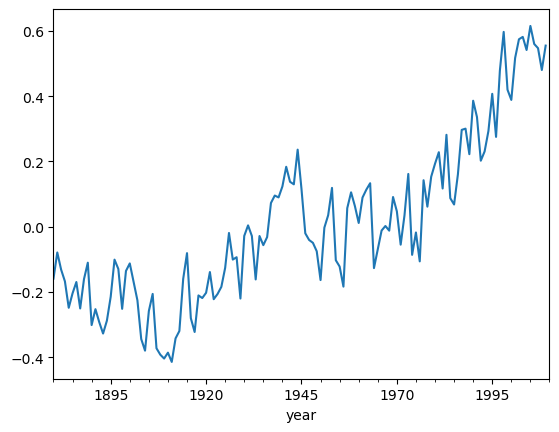

In [46]:
full_globe_temp.plot();

Also dataframes can be plotted, resulting in a line per columns, or in a plot per column when using `subplots`.

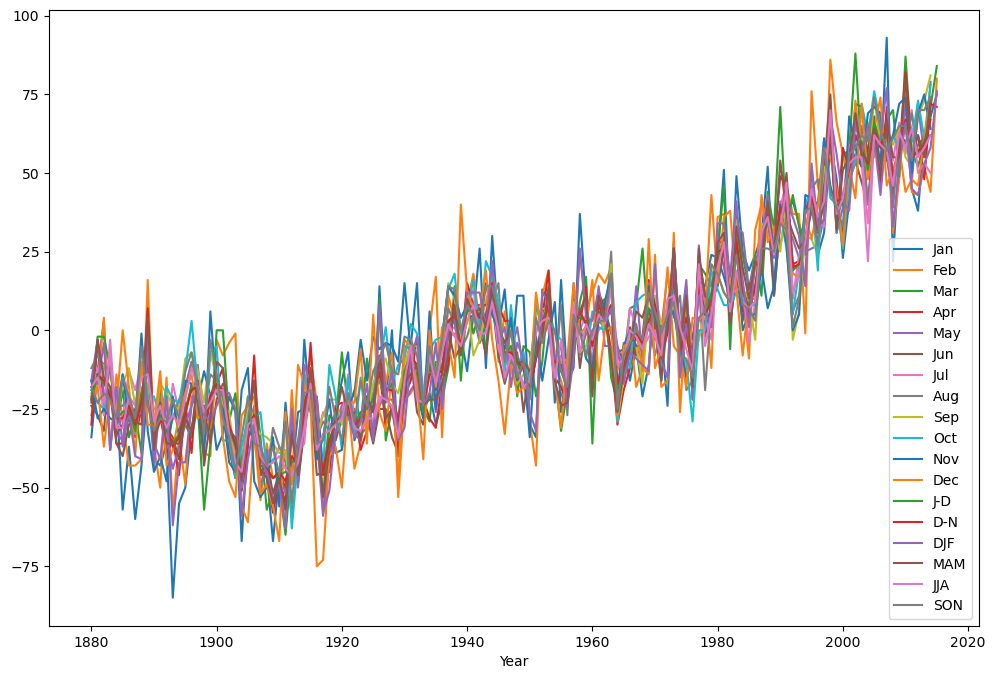

In [47]:
giss_temp.plot(figsize=LARGE_FIGSIZE);

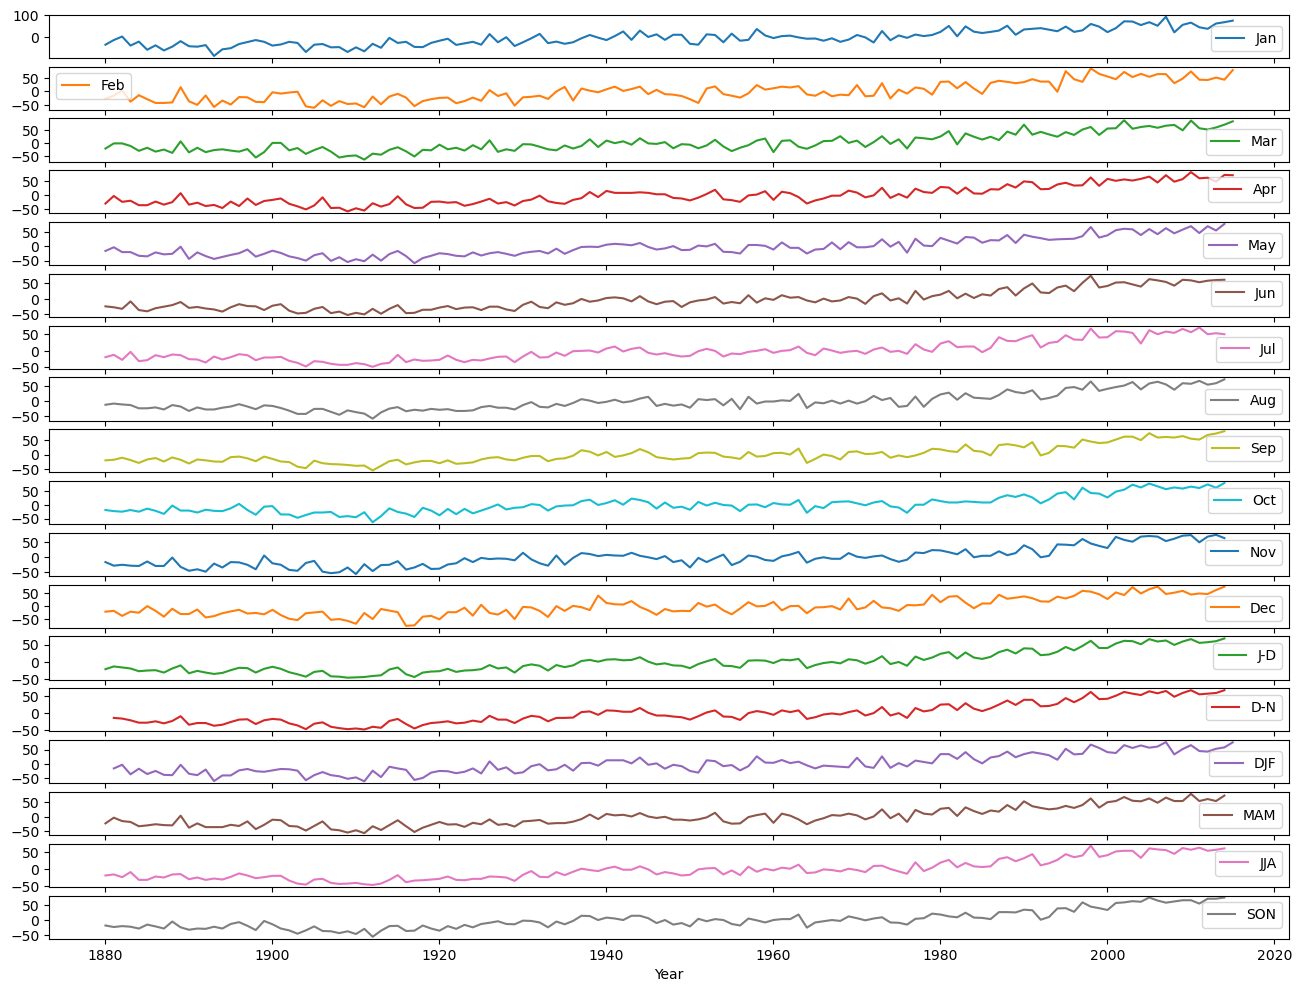

In [48]:
giss_temp.plot(subplots=True, figsize=(16, 12));

A useful plot type is a kernel distribution estimate, or `kde`.  Also a box plot is nice to get a feeling for the distribution of the values per month.

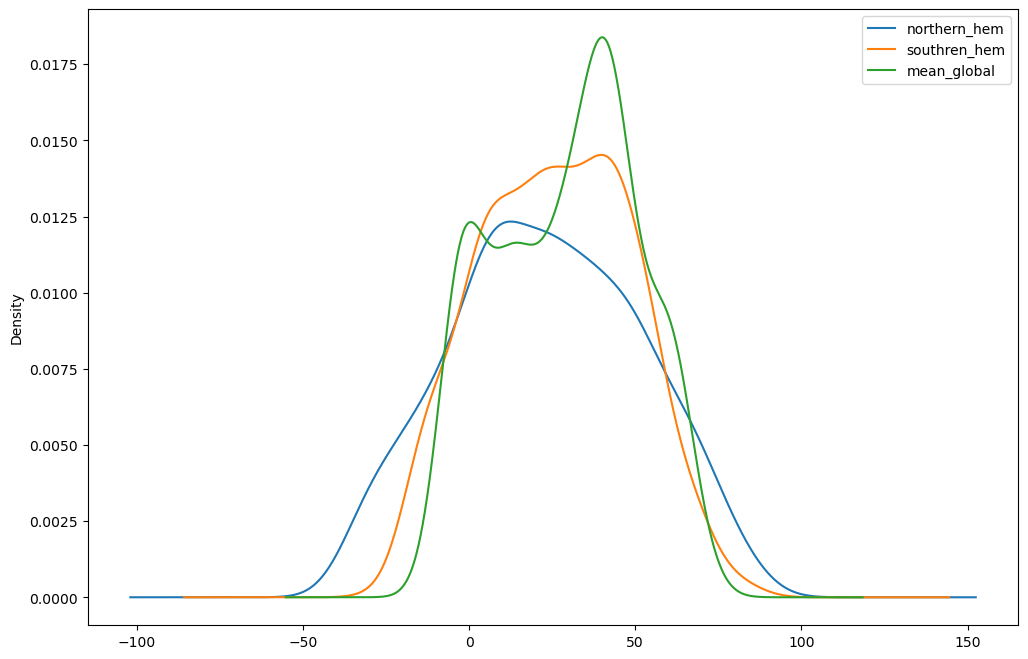

In [49]:
mean_sea_level.plot(kind='kde', figsize=(12, 8));

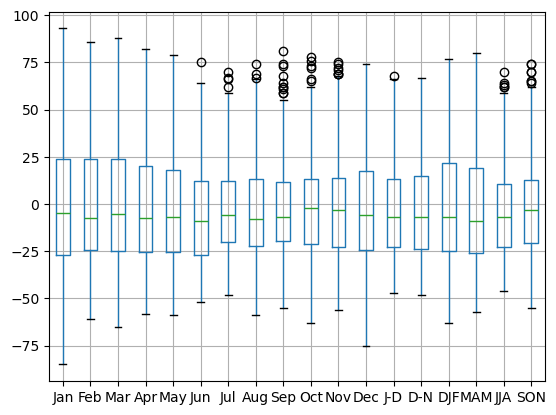

In [50]:
giss_temp.boxplot(return_type='dict');

A scatter matrix can be used to visualize the correlation between all columns of a pandas dataframe.

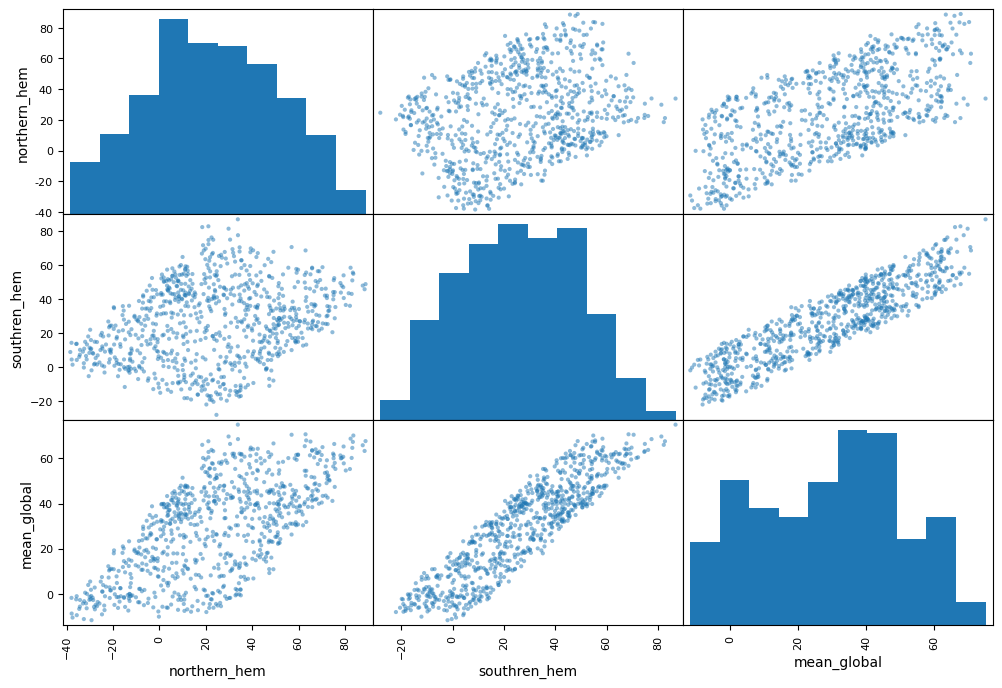

In [51]:
from pandas.plotting import scatter_matrix
scatter_matrix(mean_sea_level, figsize=LARGE_FIGSIZE);

## Accessing data in pandas data structures

In [52]:
full_globe_temp

year
1880-01-01   -0.1591
1881-01-01   -0.0789
1882-01-01   -0.1313
1883-01-01   -0.1675
1884-01-01   -0.2485
               ...  
2006-01-01    0.5601
2007-01-01    0.5472
2008-01-01    0.4804
2009-01-01    0.5551
2010-01-01       NaN
Name: mean temp, Length: 131, dtype: float64

In [53]:
my_date = pd.Timestamp('1885')
full_globe_temp[my_date]

np.float64(-0.2042)

Although it is possible to access data using the usual square bracket notation, it is more robust to use the `loc` object, or, for actual positions in dataframes, the `iloc` object part of pandas data structures.

In [54]:
full_globe_temp.loc[my_date]

np.float64(-0.2042)

In [55]:
full_globe_temp.iloc[0]

np.float64(-0.1591)

In [56]:
full_globe_temp.iloc[-1]

np.float64(nan)

In [57]:
full_globe_temp.index[-1]

Timestamp('2010-01-01 00:00:00')

Adding a row of data is possible as well.  NaN is used here since we don't have actual data.

In [58]:
full_globe_temp[pd.Timestamp('2011')] = np.nan

In [59]:
full_globe_temp.tail(5)

year
2007-01-01    0.5472
2008-01-01    0.4804
2009-01-01    0.5551
2010-01-01       NaN
2011-01-01       NaN
Name: mean temp, dtype: float64

Dataframes are accessed in a similar manner as series.

In [60]:
giss_temp['Jan']

Year
1880    -34
1881    -13
1882      3
1883    -38
1884    -20
       ... 
2011     45
2012     38
2013     62
2014     68
2015     75
Name: Jan, Length: 136, dtype: Int32

In [61]:
giss_temp.loc[1979, 'Dec']

np.int32(43)

In [62]:
giss_temp.loc[1979, 'Jan':'Jun']

Jan     10
Feb    -12
Mar     14
Apr      8
May      1
Jun      9
Name: 1979, dtype: Int32

## Ranges

Besides time stamps, it is also possible to use time period ranges as indices.  They can be constructed easily, as shown below for all months starting with January 1880, ending with December 2015.

In [63]:
giss_temp_index = pd.period_range('1/1/1880', '12/1/2015', freq='M')
giss_temp_index

PeriodIndex(['1880-01', '1880-02', '1880-03', '1880-04', '1880-05', '1880-06',
             '1880-07', '1880-08', '1880-09', '1880-10',
             ...
             '2015-03', '2015-04', '2015-05', '2015-06', '2015-07', '2015-08',
             '2015-09', '2015-10', '2015-11', '2015-12'],
            dtype='period[M]', length=1632)

## Transformations

Commonly used functions are implemented directly as methods on columns.

In [64]:
min_level, max_level = mean_sea_level.mean_global.min(), mean_sea_level.mean_global.max()

The most general way to transform columns in a dataframe is through the `apply` method that takes a function as an argument, and will apply it to each value in that column.

In [65]:
def normalize(level):
    return (level - min_level)/(max_level - min_level)

In [66]:
mean_sea_level['normalized_global'] = mean_sea_level.mean_global.apply(normalize)

<Axes: xlabel='date'>

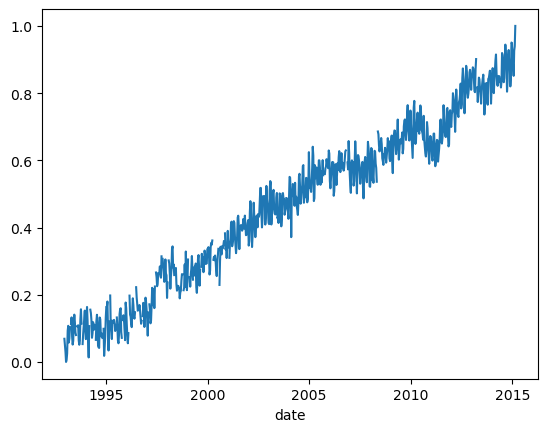

In [67]:
mean_sea_level.normalized_global.plot()

The `giss_temp` dataframe is in fact a time series over all months from 1880 till 2015, so it can be transformed into a time series indexed by year, month using the `unstack` method.

In [68]:
giss_temp_series = giss_temp.transpose().unstack()
giss_temp_series

Year     
1880  Jan     -34
      Feb     -27
      Mar     -22
      Apr     -30
      May     -16
             ... 
2015  D-N    <NA>
      DJF      76
      MAM    <NA>
      JJA    <NA>
      SON    <NA>
Length: 2448, dtype: Int32

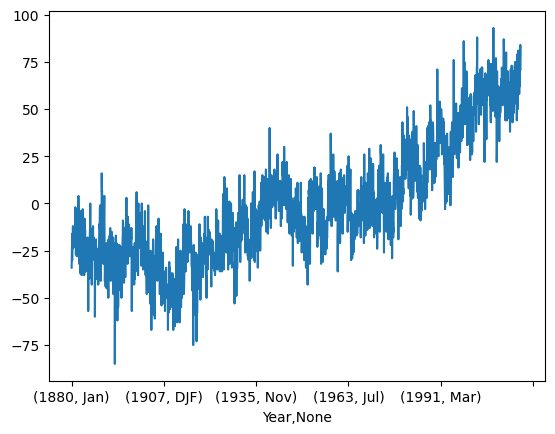

In [69]:
giss_temp_series.plot();

## Statistics

The `describe` method provides a statistical summary of the floating point data in a dataframe.

In [70]:
mean_sea_level.describe()

,northern_hem,southren_hem,mean_global,normalized_global
count,817.000000,817.000000,780.000000,780.000000
mean,23.160291,25.920989,29.166036,0.471897
std,28.443204,22.744819,21.226033,0.244531
min,-38.377000,-28.239000,-11.796000,0.000000
25%,3.133000,7.931000,11.130500,0.264121
50%,22.585000,26.220000,31.783000,0.502045
75%,45.172000,43.326000,45.047500,0.654856
max,88.856000,86.893000,75.007000,1.000000


To reduce noise in plots, rolling averages can be used, in this case over a window of 10 values.

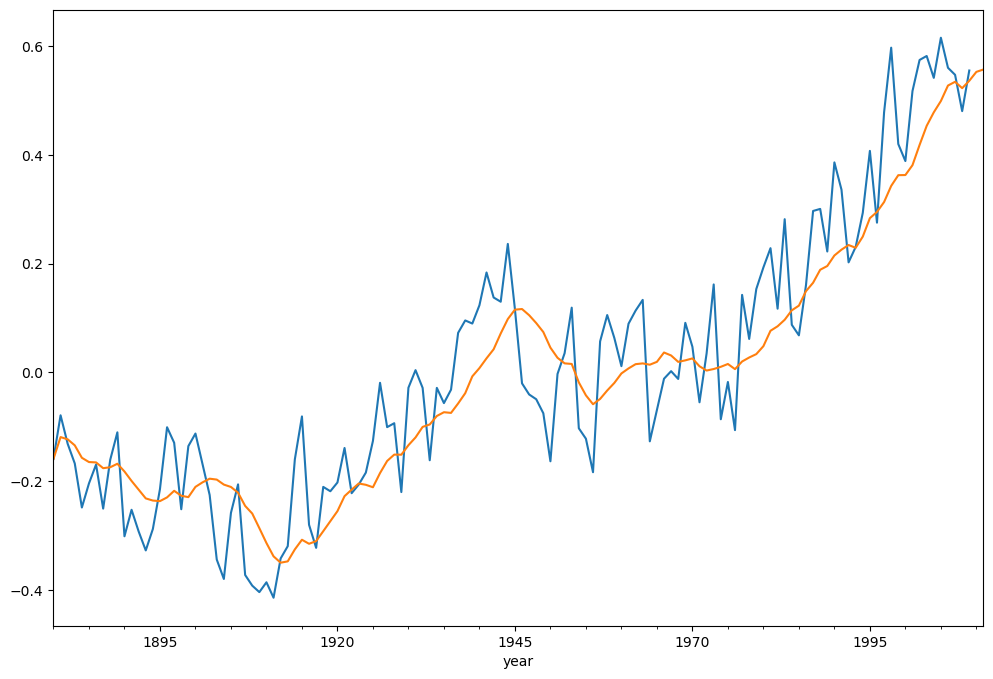

In [71]:
full_globe_temp.plot()
full_globe_temp.rolling(10, min_periods=1).mean().plot(figsize=LARGE_FIGSIZE);

## Group by

The `mean_sea_level` dataframe contains several rows for the same year, if we want to group those values, some transformations need to be done first.  We restore the original index, so that `data` is an ordinary column again.  Next, it is transformed so that only the year remains, which is stored in a new column `year`.

In [72]:
mean_sea_level

,northern_hem,southren_hem,mean_global,normalized_global
date,,,,
1992.9323,13.717,2.517,NaN,NaN
1992.9595,1.328,-7.645,-5.818,0.068869
1992.9866,-13.375,-2.267,-7.525,0.049203
1993.0138,-24.723,0.855,-9.215,0.029734
1993.0409,-29.231,-2.020,-11.796,0.000000
...,...,...,...,...
2015.0309,39.398,69.746,64.804,0.882458
2015.0580,31.524,69.317,62.115,0.851480
2015.0852,33.878,77.533,68.589,0.926062


In [73]:
mean_sea_level = mean_sea_level.reset_index()
mean_sea_level

,date,northern_hem,southren_hem,mean_global,normalized_global
0,1992.9323,13.717,2.517,NaN,NaN
1,1992.9595,1.328,-7.645,-5.818,0.068869
2,1992.9866,-13.375,-2.267,-7.525,0.049203
3,1993.0138,-24.723,0.855,-9.215,0.029734
4,1993.0409,-29.231,-2.020,-11.796,0.000000
...,...,...,...,...,...
812,2015.0309,39.398,69.746,64.804,0.882458
813,2015.0580,31.524,69.317,62.115,0.851480
814,2015.0852,33.878,77.533,68.589,0.926062
815,2015.1123,29.822,81.370,69.745,0.939380


In [74]:
mean_sea_level['year'] = mean_sea_level['date'].apply(int)
mean_sea_level

,date,northern_hem,southren_hem,mean_global,normalized_global,year
0,1992.9323,13.717,2.517,NaN,NaN,1992
1,1992.9595,1.328,-7.645,-5.818,0.068869,1992
2,1992.9866,-13.375,-2.267,-7.525,0.049203,1992
3,1993.0138,-24.723,0.855,-9.215,0.029734,1993
4,1993.0409,-29.231,-2.020,-11.796,0.000000,1993
...,...,...,...,...,...,...
812,2015.0309,39.398,69.746,64.804,0.882458,2015
813,2015.0580,31.524,69.317,62.115,0.851480,2015
814,2015.0852,33.878,77.533,68.589,0.926062,2015
815,2015.1123,29.822,81.370,69.745,0.939380,2015


The `groupby` method creates an object that one can iterate over, returning the group value, and a subdataframe for that group value.

In [75]:
grouped_sl = mean_sea_level.groupby('year')

In [76]:
for group, sub_df in grouped_sl:
    print(group)
    print(sub_df)
    print("")

1992
        date  northern_hem  southren_hem  mean_global  normalized_global  year
0  1992.9323        13.717         2.517          NaN                NaN  1992
1  1992.9595         1.328        -7.645       -5.818           0.068869  1992
2  1992.9866       -13.375        -2.267       -7.525           0.049203  1992

1993
         date  northern_hem  southren_hem  mean_global  normalized_global  \
3   1993.0138       -24.723         0.855       -9.215           0.029734   
4   1993.0409       -29.231        -2.020      -11.796           0.000000   
5   1993.0681       -32.538        -0.398      -11.291           0.005818   
6   1993.0952       -35.588         4.102       -9.569           0.025656   
7   1993.1223       -26.579         6.787       -3.714           0.093107   
..        ...           ...           ...          ...                ...   
35  1993.8825        10.529        -7.718       -4.588           0.083039   
36  1993.9096        10.772        -6.169       -2.648   

However, it also supports methods such as `mean` to compute aggregations over the values in the groups.

In [77]:
year_mean = grouped_sl.mean().drop('date', axis=1)
year_mean

,northern_hem,southren_hem,mean_global,normalized_global
year,,,,
1992,0.556667,-2.465000,-6.671500,0.059036
1993,-3.787108,-5.485378,-4.181882,0.087717
1994,-4.631432,-3.523946,-3.668971,0.093626
1995,-2.709314,-1.625171,-1.755452,0.115671
1996,-1.184541,-0.204919,0.775912,0.144833
...,...,...,...,...
2011,36.664865,43.639108,46.442865,0.670931
2012,48.506541,53.315595,57.293730,0.795937
2013,52.047757,54.749270,59.685571,0.823492


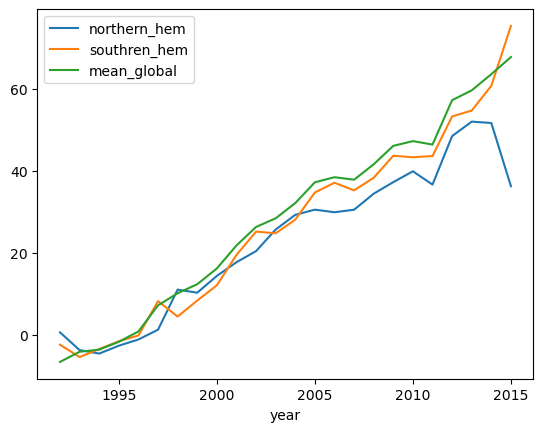

In [78]:
year_mean[['northern_hem', 'southren_hem', 'mean_global']].plot();

## Pivot tables

A nice way to explore data and perform analysis is thruogh pivot tables, an operation supported directly on pandas dataframes.

In [79]:
set_option("display.max_rows", 20)
sales

,Account,Name,Rep,Manager,Product,Quantity,Price,Status
0,714466,Trantow-Barrows,Craig Booker,Debra Henley,CPU,1,30000,presented
1,714466,Trantow-Barrows,Craig Booker,Debra Henley,Software,1,10000,presented
2,714466,Trantow-Barrows,Craig Booker,Debra Henley,Maintenance,2,5000,pending
3,737550,"Fritsch, Russel and Anderson",Craig Booker,Debra Henley,CPU,1,35000,declined
4,146832,Kiehn-Spinka,Daniel Hilton,Debra Henley,CPU,2,65000,won
5,218895,Kulas Inc,Daniel Hilton,Debra Henley,CPU,2,40000,pending
6,218895,Kulas Inc,Daniel Hilton,Debra Henley,Software,1,10000,presented
7,412290,Jerde-Hilpert,John Smith,Debra Henley,Maintenance,2,5000,pending
8,740150,Barton LLC,John Smith,Debra Henley,CPU,1,35000,declined
9,141962,Herman LLC,Cedric Moss,Fred Anderson,CPU,2,65000,won


The `Status` column is in fact categorical data, so we could transfrom that column using the `astype` method,
```
sales['Status'] = sales['Status'].astype('category')
```
We can set the order of the categorical values to suite our needs.  This will determine the sort order on this column.
```
sales['Status'].cat.set_categories(['won', 'presented', 'pending', 'declined'], inplace=True)
```
However, this brakes things badly later on, so we'll only do that once the bugs have been exterminated.

We want to know the sales by product and status, and are interested in the total price and quantity.

In [80]:
sales.pivot_table(index='Product', values=['Price', 'Quantity'], columns=['Status'], aggfunc='sum')

Price                              Quantity                    \
Status       declined  pending presented       won declined pending presented   
Product                                                                         
CPU          135000.0  40000.0   60000.0  230000.0      4.0     2.0       2.0   
Maintenance       NaN  15000.0       NaN    7000.0      NaN     5.0       NaN   
Monitor           NaN      NaN    5000.0       NaN      NaN     NaN       2.0   
Software          NaN      NaN   30000.0       NaN      NaN     NaN       3.0   

                  
Status       won  
Product           
CPU          9.0  
Maintenance  3.0  
Monitor      NaN  
Software     NaN

Of course, this yields some NaNs where no data is available, e.g., `Maintenance` has no `presented` or `declined` entries.  However, it would be more semantically correct to replace the NaNs by 0, since that is the actual intent.

In [81]:
sales.pivot_table(index='Product', values=['Price', 'Quantity'], columns=['Status'],
                  aggfunc='sum', fill_value=0)

Price                           Quantity                      
Status      declined pending presented     won declined pending presented won
Product                                                                      
CPU           135000   40000     60000  230000        4       2         2   9
Maintenance        0   15000         0    7000        0       5         0   3
Monitor            0       0      5000       0        0       0         2   0
Software           0       0     30000       0        0       0         3   0

Compute the average sales price per product status.

In [82]:
table = sales.pivot_table(index=['Product', 'Status'], values=['Price', 'Quantity'],
                          fill_value=0, aggfunc={'Price': ['mean', len], 'Quantity': 'sum'})
table

Price               Quantity
                        len          mean      sum
Product     Status                                
CPU         declined      3  45000.000000        4
            pending       1  40000.000000        2
            presented     2  30000.000000        2
            won           3  76666.666667        9
Maintenance pending       3   5000.000000        5
            won           1   7000.000000        3
Monitor     presented     1   5000.000000        2
Software    presented     3  10000.000000        3

Now we can query the table to get only the data for the status `won`.

In [83]:
table.query("Status == ['won']")

Price               Quantity
                     len          mean      sum
Product     Status                             
CPU         won        3  76666.666667        9
Maintenance won        1   7000.000000        3

The `table` object is just a pandas dataframe, so individual values can be obtained in the usual way.

In [84]:
table.loc['CPU', 'pending']['Price', 'mean']

np.float64(40000.0)